# 📊 Customer Segmentation & Sales Analysis

This project analyzes real-world e-commerce transaction data to understand customer behavior, sales trends, and business insights using Python.

In [1]:
!pip install pd
import pandas as pd

## 📁 Data Loading & Overview

In this step, we load the dataset and explore its structure to understand the available features such as customer ID, invoice details, product information, and pricing.

In [2]:
df=pd.read_excel("Online+Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 🧹 Data Cleaning

Data cleaning is performed to ensure accuracy and reliability of analysis.

Steps performed:
- Removed missing values
- Filtered out cancelled orders (InvoiceNo starting with 'C')
- Converted InvoiceDate to proper datetime format

In [13]:
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [21]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()

In [22]:
df.loc['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## ⚙️ Feature Engineering

New features are created to enhance analysis:

- **TotalPrice** = Quantity × UnitPrice
- Extracted **Month** and **Year** from InvoiceDate

These features help in understanding revenue trends and time-based patterns.

In [23]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [24]:
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

## 📊 Customer Analysis

This section focuses on understanding customer behavior:

- Identified top customers based on total spending
- Calculated number of unique customers
- Analyzed country-wise sales distribution

In [25]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0     259657.3
17450.0    194550.79
16446.0     168472.5
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0      77183.6
Name: TotalPrice, dtype: object


In [26]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0     259657.3
17450.0    194550.79
16446.0     168472.5
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0      77183.6
Name: TotalPrice, dtype: object


In [27]:
unique_customers = df['CustomerID'].nunique()
print(unique_customers)

4339


## 🔥 RFM Analysis (Customer Segmentation)

RFM analysis is used to evaluate customer value:

- **Recency** → How recently a customer made a purchase
- **Frequency** → How often they purchase
- **Monetary** → How much they spend

This helps in identifying high-value and loyal customers.

In [28]:
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.6
12347.0,2,7,4310.0
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.4


## 📈 Data Visualization

Visualizations are used to present insights clearly:

- Bar Chart → Top 10 customers by spending
- Pie Chart → Country-wise sales distribution
- Line Chart → Monthly sales trend

These charts help in understanding patterns and business performance.

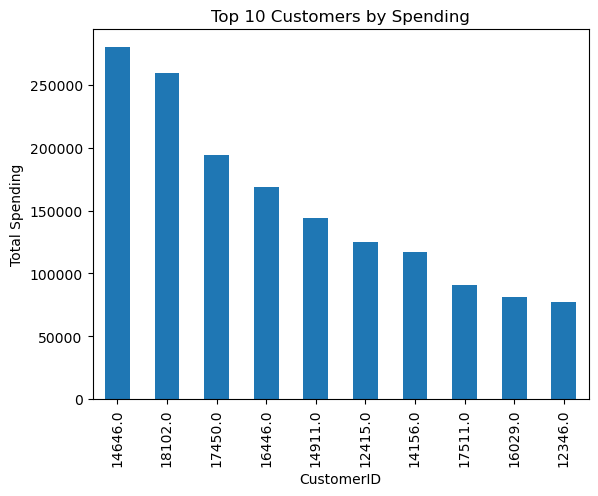

In [29]:
import matplotlib.pyplot as plt

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("CustomerID")
plt.ylabel("Total Spending")
plt.show() 

In [32]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

C:\Users\DURGA DAMAI\AppData\Local\Temp\ipykernel_27660\1649739143.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  country_sales.head(5).plot(kind='pie', autopct='%1.1f%%')


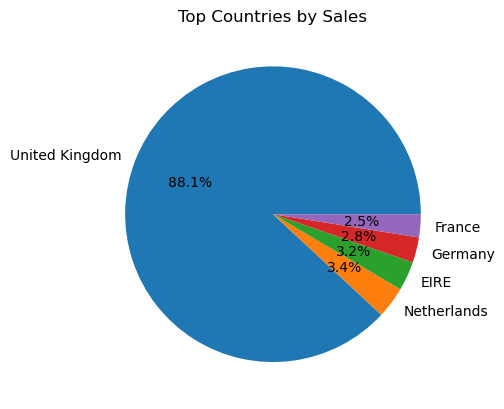

In [33]:
country_sales.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Countries by Sales")
plt.ylabel('')
plt.show()

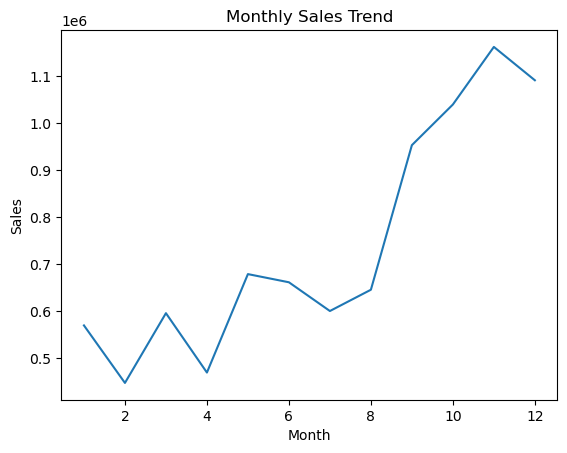

In [34]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## 💡 Key Insights

- A small group of customers contributes significantly to total revenue
- Certain countries dominate overall sales
- Sales show variation across months indicating seasonal trends
- High-frequency customers tend to generate higher revenue

## 🚀 Conclusion

This project demonstrates how data analysis can uncover valuable business insights. Using Python and Pandas, we explored customer behavior, sales trends, and segmentation techniques that can support data-driven decision-making.